In [1]:
# installing all the required libraries first
!pip install datasets nltk spacy scikit-learn gensim matplotlib seaborn wordcloud
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 35.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 97.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
# importing everything we need upfront
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

import spacy

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from gensim.models import Word2Vec

from datasets import load_dataset

import warnings
warnings.filterwarnings('ignore')

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [7]:
# loading the dataset from huggingface - using yelp_polarity since it has customer review text
# which is very relevant for the media company use case
dataset = load_dataset("yelp_polarity", split="train[:2000]")
df = pd.DataFrame(dataset)
df.columns = ['text', 'label'] # Swapping 'text' and 'label' to correct column assignment
print(df.shape)
df.head()

(2000, 2)


,text,label
0,"Unfortunately, the frustration of being Dr. Go...",0
1,Been going to Dr. Goldberg for over 10 years. ...,1
2,I don't know what Dr. Goldberg was like before...,0
3,I'm writing this review to give you a heads up...,0
4,All the food is great here. But the best thing...,1


In [4]:
# quick look at the data
print(df['text'][0])
print("\nlabel distribution:")
print(df['label'].value_counts())

0

label distribution:
label
I wanted to like it here... in fact, I have in the past. We used to come here for college events and schedule ahead of time for a large group - then again, this was always on weeknights... when they were slow... thank goodness. I always loved the food here (then again, these dishes aren't anything scientific - they are basic - comfort food), and I thought the gigantic restaurant could handle large groups well... until I brought 10 people here for a birthday dinner on a Saturday. \n\nFirst of all, we had reservations but still stood awkwardly in the waiting area for a while to be seated. Not terrible. Then we were seated - the server was flustered and irritated before we had a chance to speak. Long story short, we waited 1.5 hours for our food (pasta... yes - the stuff you make at home for an entire family in 10 minutes), the waitress spent all her time coming to her table bashing the kitchen staff to us (not exactly professional), and the manager was no whe

In [8]:
# step 1 - text cleaning
# removing urls, special characters, numbers, extra whitespace and converting to lowercase

def clean_text(text):
    # lowercase
    text = text.lower()
    # remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # remove HTML tags if any
    text = re.sub(r'<.*?>', '', text)
    # remove numbers
    text = re.sub(r'\d+', '', text)
    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_text'] = df['text'].apply(clean_text)

# comparing before and after
print("Original:")
print(df['text'][0])
print("\nCleaned:")
print(df['cleaned_text'][0])

Original:
Unfortunately, the frustration of being Dr. Goldberg's patient is a repeat of the experience I've had with so many other doctors in NYC -- good doctor, terrible staff.  It seems that his staff simply never answers the phone.  It usually takes 2 hours of repeated calling to get an answer.  Who has time for that or wants to deal with it?  I have run into this problem with many other doctors and I just don't get it.  You have office workers, you have patients with medical needs, why isn't anyone answering the phone?  It's incomprehensible and not work the aggravation.  It's with regret that I feel that I have to give Dr. Goldberg 2 stars.

Cleaned:
unfortunately the frustration of being dr goldbergs patient is a repeat of the experience ive had with so many other doctors in nyc good doctor terrible staff it seems that his staff simply never answers the phone it usually takes hours of repeated calling to get an answer who has time for that or wants to deal with it i have run into

In [9]:
# step 2 - tokenization using NLTK
# breaking the text into individual word tokens

df['tokens'] = df['cleaned_text'].apply(word_tokenize)

print("Sample tokens:")
print(df['tokens'][0][:20])
print(f"\nTotal tokens in first review: {len(df['tokens'][0])}")

Sample tokens:
['unfortunately', 'the', 'frustration', 'of', 'being', 'dr', 'goldbergs', 'patient', 'is', 'a', 'repeat', 'of', 'the', 'experience', 'ive', 'had', 'with', 'so', 'many', 'other']

Total tokens in first review: 112


In [10]:
# step 3 - stopword removal
# removing common words like 'the', 'is', 'in' which don't carry much meaning

stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words and len(word) > 2]

df['filtered_tokens'] = df['tokens'].apply(remove_stopwords)

print("Before stopword removal:")
print(df['tokens'][0][:20])
print("\nAfter stopword removal:")
print(df['filtered_tokens'][0][:20])
print(f"\nToken count reduced from {len(df['tokens'][0])} to {len(df['filtered_tokens'][0])}")

Before stopword removal:
['unfortunately', 'the', 'frustration', 'of', 'being', 'dr', 'goldbergs', 'patient', 'is', 'a', 'repeat', 'of', 'the', 'experience', 'ive', 'had', 'with', 'so', 'many', 'other']

After stopword removal:
['unfortunately', 'frustration', 'goldbergs', 'patient', 'repeat', 'experience', 'ive', 'many', 'doctors', 'nyc', 'good', 'doctor', 'terrible', 'staff', 'seems', 'staff', 'simply', 'never', 'answers', 'phone']

Token count reduced from 112 to 53


In [11]:
# step 4 - lemmatization
# converting words to their base/root form using both NLTK and SpaCy
# using spacy as it's more accurate for production use

nlp = spacy.load('en_core_web_sm')

# NLTK lemmatizer as well for comparison
lemmatizer = WordNetLemmatizer()

def lemmatize_nltk(tokens):
    return [lemmatizer.lemmatize(token) for token in tokens]

def lemmatize_spacy(text):
    doc = nlp(text)
    return [token.lemma_ for token in doc if token.text not in stop_words and len(token.text) > 2 and not token.is_punct]

# applying NLTK lemmatization
df['lemmatized_nltk'] = df['filtered_tokens'].apply(lemmatize_nltk)

# applying spacy lemmatization on cleaned text
df['lemmatized_spacy'] = df['cleaned_text'].apply(lemmatize_spacy)

print("NLTK Lemmatization:")
print(df['lemmatized_nltk'][0][:15])
print("\nSpaCy Lemmatization:")
print(df['lemmatized_spacy'][0][:15])

NLTK Lemmatization:
['unfortunately', 'frustration', 'goldberg', 'patient', 'repeat', 'experience', 'ive', 'many', 'doctor', 'nyc', 'good', 'doctor', 'terrible', 'staff', 'seems']

SpaCy Lemmatization:
['unfortunately', 'frustration', 'goldbergs', 'patient', 'repeat', 'experience', 'many', 'doctor', 'nyc', 'good', 'doctor', 'terrible', 'staff', 'seem', 'staff']


In [12]:
# joining lemmatized tokens back to string for vectorization steps
df['processed_text'] = df['lemmatized_spacy'].apply(lambda x: ' '.join(x))
print(df['processed_text'][0])

unfortunately frustration goldbergs patient repeat experience many doctor nyc good doctor terrible staff seem staff simply never answer phone usually take hour repeat call get answer time want deal run problem many doctor get office worker patient medical need anyone answer phone incomprehensible work aggravation regret feel give goldberg star


In [13]:
# step 5 - vocabulary creation
# building a vocabulary from all the processed tokens

all_tokens = [token for tokens in df['lemmatized_spacy'] for token in tokens]

from collections import Counter
vocab_freq = Counter(all_tokens)

vocab = sorted(vocab_freq.keys())
print(f"Total unique words in vocabulary: {len(vocab)}")
print(f"\nTop 20 most common words:")
print(vocab_freq.most_common(20))

Total unique words in vocabulary: 12771

Top 20 most common words:
[('get', 1544), ('good', 1319), ('food', 1297), ('place', 1292), ('like', 1049), ('time', 891), ('one', 871), ('order', 859), ('would', 836), ('come', 765), ('go', 761), ('make', 709), ('well', 690), ('back', 667), ('great', 663), ('take', 657), ('say', 657), ('service', 630), ('really', 611), ('even', 569)]


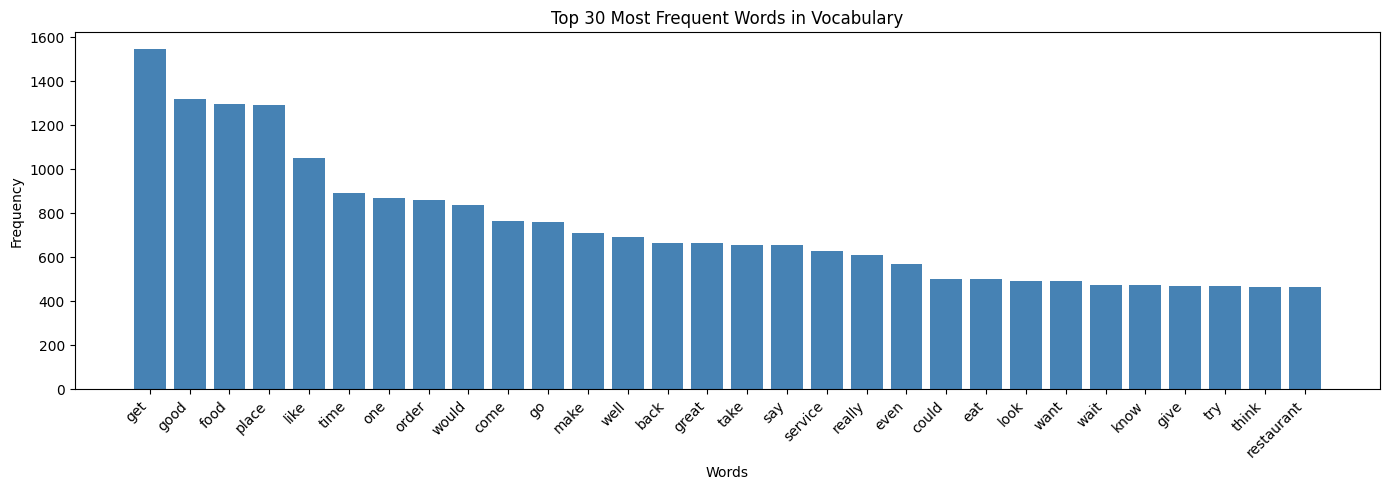

In [14]:
# visualizing the vocabulary - top 30 words
top_words = dict(vocab_freq.most_common(30))
plt.figure(figsize=(14, 5))
plt.bar(top_words.keys(), top_words.values(), color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('Top 30 Most Frequent Words in Vocabulary')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [15]:
# step 6 - Bag of Words and TF-IDF vectors
# using sklearn's CountVectorizer for BoW and TfidfVectorizer for TF-IDF

# taking a smaller subset to keep it manageable
sample_texts = df['processed_text'].tolist()[:500]

# Bag of Words
bow_vectorizer = CountVectorizer(max_features=1000)
bow_matrix = bow_vectorizer.fit_transform(sample_texts)

print("Bag of Words Matrix Shape:", bow_matrix.shape)
print("Sample BoW vector (first 10 values):", bow_matrix.toarray()[0][:10])

Bag of Words Matrix Shape: (500, 1000)
Sample BoW vector (first 10 values): [0 0 0 0 0 0 0 0 0 0]


In [16]:
# TF-IDF - gives more weight to rare but important words
tfidf_vectorizer = TfidfVectorizer(max_features=1000)
tfidf_matrix = tfidf_vectorizer.fit_transform(sample_texts)

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)
print("Sample TF-IDF vector (first 10 values):", tfidf_matrix.toarray()[0][:10])

# looking at top tfidf terms for first document
feature_names = tfidf_vectorizer.get_feature_names_out()
first_doc_tfidf = tfidf_matrix.toarray()[0]
top_indices = first_doc_tfidf.argsort()[-10:][::-1]
print("\nTop TF-IDF terms in first document:")
for idx in top_indices:
    if first_doc_tfidf[idx] > 0:
        print(f"  {feature_names[idx]}: {first_doc_tfidf[idx]:.4f}")

TF-IDF Matrix Shape: (500, 1000)
Sample TF-IDF vector (first 10 values): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Top TF-IDF terms in first document:
  doctor: 0.5404
  answer: 0.4063
  repeat: 0.3101
  phone: 0.2549
  many: 0.2093
  staff: 0.1817
  office: 0.1518
  worker: 0.1518
  unfortunately: 0.1437
  simply: 0.1414


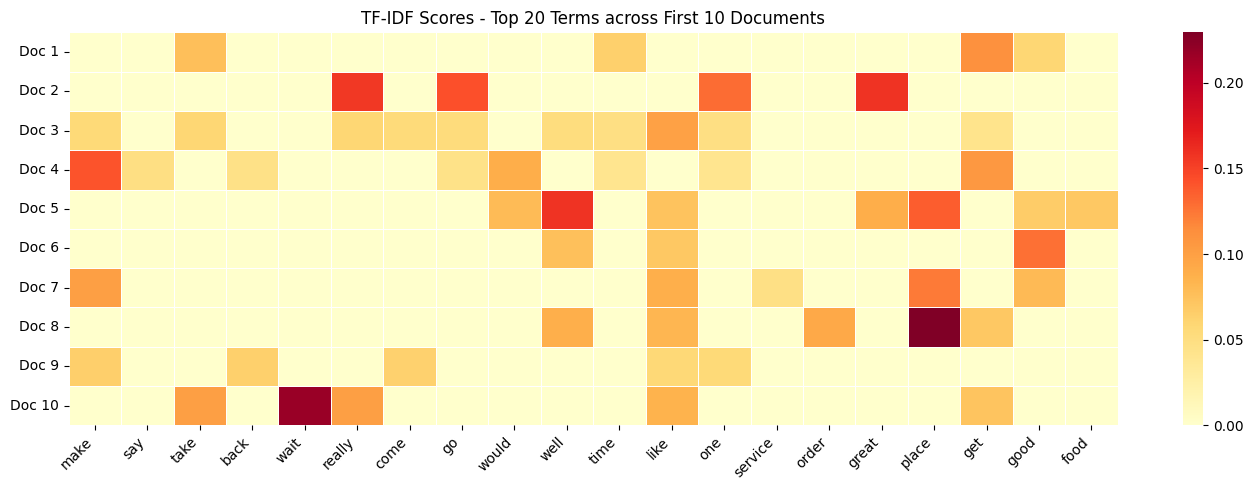

In [17]:
# visualizing TF-IDF as a heatmap for first 10 docs and top 20 terms
top_20_features = feature_names[np.argsort(tfidf_matrix.toarray().sum(axis=0))[-20:]]
top_20_indices = [list(feature_names).index(f) for f in top_20_features]
heatmap_data = tfidf_matrix.toarray()[:10, top_20_indices]

plt.figure(figsize=(14, 5))
sns.heatmap(heatmap_data, xticklabels=top_20_features, yticklabels=[f'Doc {i+1}' for i in range(10)],
            cmap='YlOrRd', linewidths=0.5)
plt.title('TF-IDF Scores - Top 20 Terms across First 10 Documents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [18]:
# step 7 - Word Embeddings using Gensim Word2Vec
# training on our corpus so the embeddings reflect the review domain

tokenized_corpus = df['lemmatized_spacy'].tolist()[:500]

# training Word2Vec model
# vector_size=100 means each word gets a 100-dimensional vector
# window=5 means context of 5 words on each side
# min_count=2 ignores words that appear less than 2 times
w2v_model = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=10,
    sg=0  # using CBOW
)

print(f"Vocabulary size: {len(w2v_model.wv.key_to_index)}")
print(f"Vector size: {w2v_model.vector_size}")

Vocabulary size: 2533
Vector size: 100


In [19]:
# testing the word2vec model - words similar to 'food'
print("Words similar to 'food':")
try:
    similar_words = w2v_model.wv.most_similar('food', topn=10)
    for word, score in similar_words:
        print(f"  {word}: {score:.4f}")
except KeyError:
    print("word 'food' not in vocabulary, trying 'place'")
    similar_words = w2v_model.wv.most_similar('place', topn=10)
    for word, score in similar_words:
        print(f"  {word}: {score:.4f}")

Words similar to 'food':
  since: 0.9997
  think: 0.9997
  even: 0.9997
  one: 0.9997
  old: 0.9997
  appetizer: 0.9997
  still: 0.9997
  way: 0.9997
  come: 0.9997
  also: 0.9997


In [20]:
# step 8 - Sentence Embeddings
# averaging word vectors to get a single vector per review (mean pooling)
# simple but effective approach

def get_sentence_embedding(tokens, model):
    vectors = []
    for token in tokens:
        if token in model.wv:
            vectors.append(model.wv[token])
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

# getting sentence embeddings for the sample
sentence_embeddings = np.array([
    get_sentence_embedding(tokens, w2v_model)
    for tokens in df['lemmatized_spacy'].tolist()[:500]
])

print(f"Sentence embeddings shape: {sentence_embeddings.shape}")
print(f"First sentence embedding (first 10 values): {sentence_embeddings[0][:10]}")

Sentence embeddings shape: (500, 100)
First sentence embedding (first 10 values): [-0.20831279  0.35994074  0.03690028  0.03051537  0.08188358 -0.64874941
  0.0900005   0.73227453 -0.13331115 -0.23875585]


In [21]:
# step 9 - Similarity Search
# finding similar reviews using cosine similarity on sentence embeddings

def find_similar_reviews(query_idx, embeddings, texts, top_n=5):
    query_vec = embeddings[query_idx].reshape(1, -1)
    similarity_scores = cosine_similarity(query_vec, embeddings)[0]
    # sorting by similarity, excluding the query itself
    similar_indices = similarity_scores.argsort()[::-1][1:top_n+1]
    return similar_indices, similarity_scores[similar_indices]

# testing with the first review
query_idx = 0
original_texts = df['text'].tolist()[:500]

print("Query Review:")
print(original_texts[query_idx][:200])
print("\n" + "="*60)

similar_idx, scores = find_similar_reviews(query_idx, sentence_embeddings, original_texts)

print("\nTop 5 Similar Reviews:")
for rank, (idx, score) in enumerate(zip(similar_idx, scores), 1):
    print(f"\n[Rank {rank}] Similarity Score: {score:.4f}")
    print(original_texts[idx][:200])

Query Review:
Unfortunately, the frustration of being Dr. Goldberg's patient is a repeat of the experience I've had with so many other doctors in NYC -- good doctor, terrible staff.  It seems that his staff simply 


Top 5 Similar Reviews:

[Rank 1] Similarity Score: 1.0000
I'm writing this review to give you a heads up before you see this Doctor. The office staff and administration are very unprofessional. I left a message with multiple people regarding my bill, and no 

[Rank 2] Similarity Score: 1.0000
You would think their exorbitant prices would at least buy some decent customer service. Not at this location. \n\nThey are totally understaffed and have almost nobody able or willing to help you find

[Rank 3] Similarity Score: 1.0000
Other people may have had a better experience with this company but that was not the case for us.  We had rented a limo/bus for a bachelor party.  Our driver Scott, was completely clueless in navigati

[Rank 4] Similarity Score: 1.0000
I don't know what

In [22]:
# also doing similarity search using TF-IDF vectors for comparison
# this is keyword-based while w2v is semantic

def find_similar_tfidf(query_idx, tfidf_mat, texts, top_n=5):
    query_vec = tfidf_mat[query_idx]
    scores = cosine_similarity(query_vec, tfidf_mat)[0]
    top_indices = scores.argsort()[::-1][1:top_n+1]
    return top_indices, scores[top_indices]

tfidf_idx, tfidf_scores = find_similar_tfidf(0, tfidf_matrix, sample_texts)

print("TF-IDF Based Similar Reviews for the same query:")
for rank, (idx, score) in enumerate(zip(tfidf_idx, tfidf_scores), 1):
    print(f"\n[Rank {rank}] TF-IDF Similarity: {score:.4f}")
    print(original_texts[idx][:200])

TF-IDF Based Similar Reviews for the same query:

[Rank 1] TF-IDF Similarity: 0.4168
I don't know what Dr. Goldberg was like before  moving to Arizona, but let me tell you, STAY AWAY from this doctor and this office. I was going to Dr. Johnson before he left and Goldberg took over whe

[Rank 2] TF-IDF Similarity: 0.2718
I'm writing this review to give you a heads up before you see this Doctor. The office staff and administration are very unprofessional. I left a message with multiple people regarding my bill, and no 

[Rank 3] TF-IDF Similarity: 0.1820
In all fairness - I did not see this dentist but did schedule an appointment and waited 15 minutes for them to open.\n\nWhen I look at Yelp reviews, I usually weed out the outliers (the best and the w

[Rank 4] TF-IDF Similarity: 0.1484
The times I've been here, its been an OK experience. However, their store hours are absolutely terrible. Closing at 7pm basically means they're never open when I would need to go there. Despite this b

[R

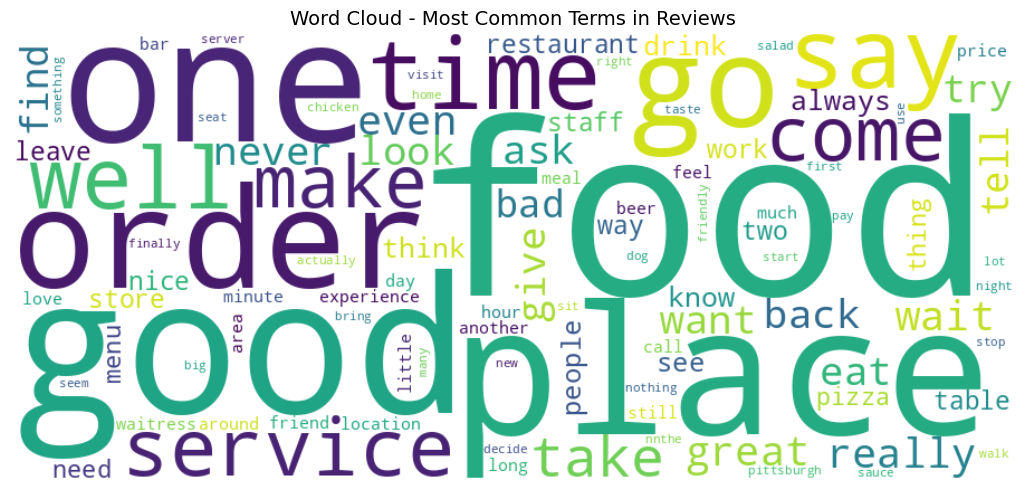

In [23]:
# step 10 - Insights and Visualization
# putting together some meaningful visualizations to understand the corpus

# 10a - word cloud of the most frequent terms
all_processed = ' '.join(df['processed_text'].tolist()[:500])
wordcloud = WordCloud(width=900, height=400, background_color='white',
                      max_words=100, colormap='viridis').generate(all_processed)

plt.figure(figsize=(14, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Most Common Terms in Reviews', fontsize=14)
plt.tight_layout()
plt.show()

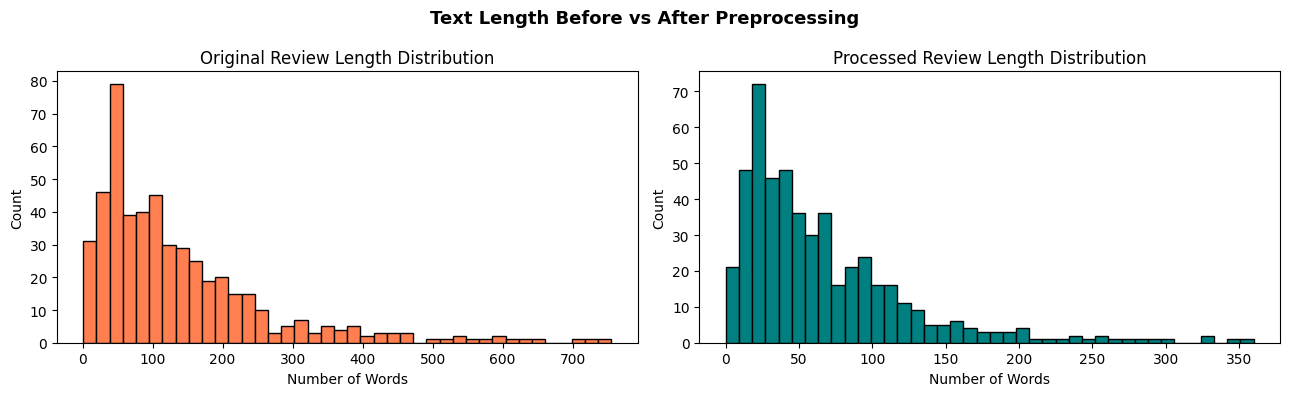

Average original length: 137.4 words
Average processed length: 65.8 words
Compression ratio: 52.2%


In [24]:
# 10b - review length distribution before and after cleaning
df['original_len'] = df['text'].apply(lambda x: len(x.split()))
df['processed_len'] = df['processed_text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['original_len'][:500], bins=40, color='coral', edgecolor='black')
axes[0].set_title('Original Review Length Distribution')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Count')

axes[1].hist(df['processed_len'][:500], bins=40, color='teal', edgecolor='black')
axes[1].set_title('Processed Review Length Distribution')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Count')

plt.suptitle('Text Length Before vs After Preprocessing', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Average original length: {df['original_len'][:500].mean():.1f} words")
print(f"Average processed length: {df['processed_len'][:500].mean():.1f} words")
print(f"Compression ratio: {(1 - df['processed_len'][:500].mean()/df['original_len'][:500].mean())*100:.1f}%")

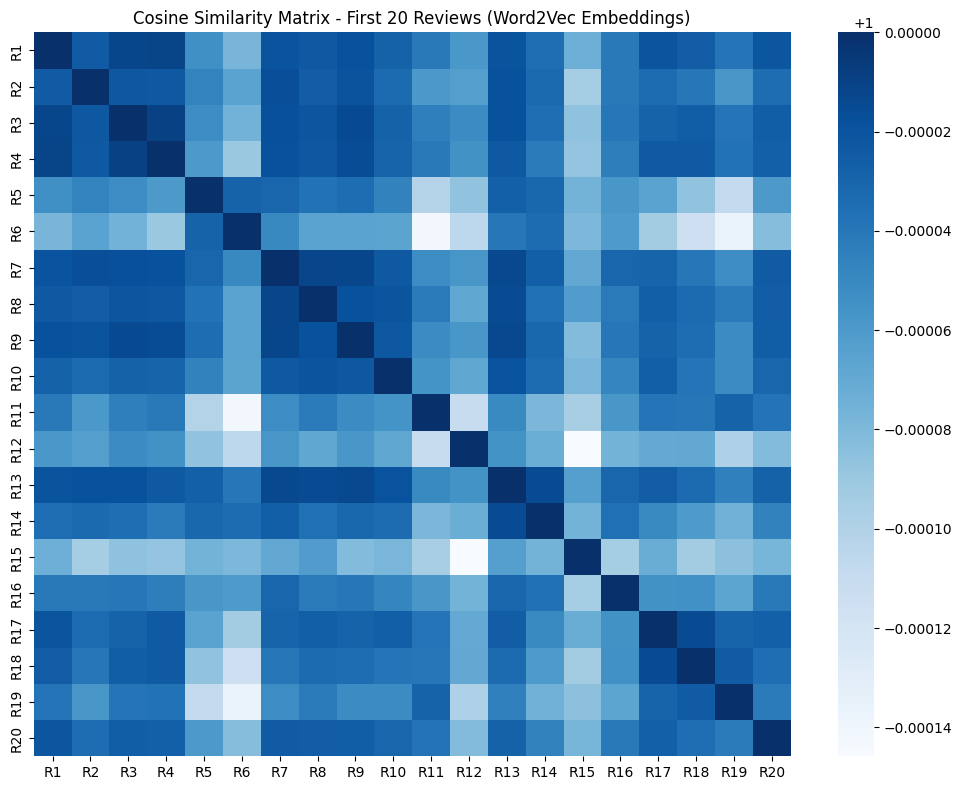

In [25]:
# 10c - cosine similarity heatmap for a small sample of reviews
# this shows how similar different reviews are to each other
n = 20
sim_matrix = cosine_similarity(sentence_embeddings[:n])

plt.figure(figsize=(10, 8))
sns.heatmap(sim_matrix, annot=False, cmap='Blues',
            xticklabels=[f'R{i+1}' for i in range(n)],
            yticklabels=[f'R{i+1}' for i in range(n)])
plt.title('Cosine Similarity Matrix - First 20 Reviews (Word2Vec Embeddings)')
plt.tight_layout()
plt.show()

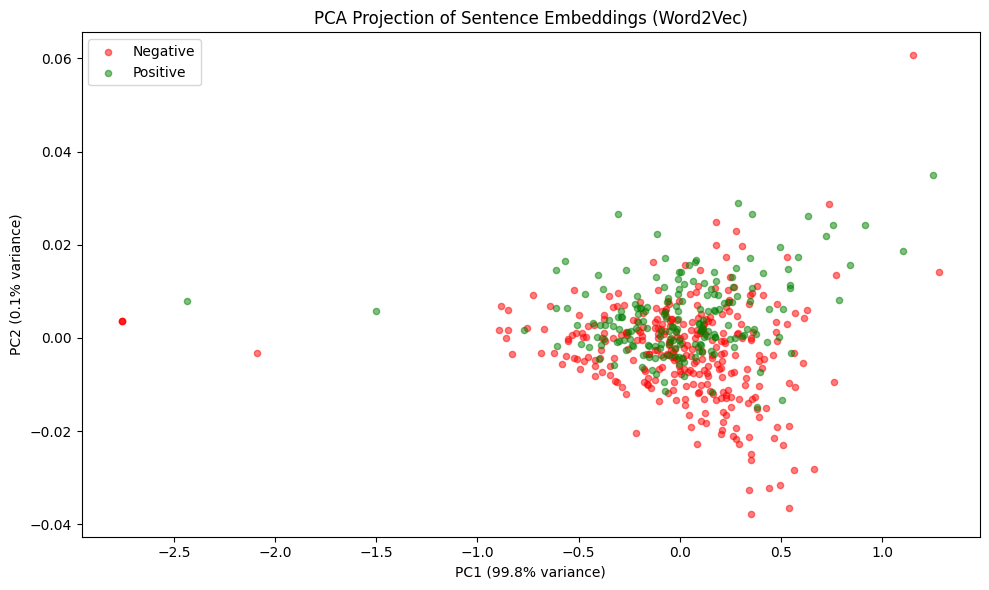

In [26]:
# 10d - reducing dimensions with PCA and plotting the embeddings
# to see if positive and negative reviews cluster differently
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(sentence_embeddings[:500])

labels = df['label'].tolist()[:500]
colors = ['red' if l == 0 else 'green' for l in labels]
label_names = ['Negative' if l == 0 else 'Positive' for l in labels]

plt.figure(figsize=(10, 6))
for label, color, name in [(0, 'red', 'Negative'), (1, 'green', 'Positive')]:
    mask = [i for i, l in enumerate(labels) if l == label]
    plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
                c=color, label=name, alpha=0.5, s=20)

plt.title('PCA Projection of Sentence Embeddings (Word2Vec)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
# 10e - summary of the full pipeline
print("=" * 60)
print("NLP PIPELINE SUMMARY")
print("=" * 60)
print(f"Total reviews processed    : {len(df)}")
print(f"Vocabulary size            : {len(vocab)}")
print(f"BoW matrix shape           : {bow_matrix.shape}")
print(f"TF-IDF matrix shape        : {tfidf_matrix.shape}")
print(f"Word2Vec vocab size        : {len(w2v_model.wv.key_to_index)}")
print(f"Word2Vec embedding dim     : {w2v_model.vector_size}")
print(f"Sentence embedding shape   : {sentence_embeddings.shape}")
print(f"Avg token reduction        : {(1 - df['processed_len'].mean()/df['original_len'].mean())*100:.1f}%")
print("=" * 60)
print("Pipeline Steps Completed:")
steps = [
    "1. Text Cleaning",
    "2. Tokenization (NLTK)",
    "3. Stopword Removal",
    "4. Lemmatization (NLTK + SpaCy)",
    "5. Vocabulary Creation",
    "6. Bag of Words + TF-IDF Vectors (Scikit-learn)",
    "7. Word Embeddings (Gensim Word2Vec)",
    "8. Sentence Embeddings (Mean Pooling)",
    "9. Similarity Search (Cosine Similarity)",
    "10. Insights & Visualization"
]
for step in steps:
    print(f"  [OK] {step}")

NLP PIPELINE SUMMARY
Total reviews processed    : 2000
Vocabulary size            : 12771
BoW matrix shape           : (500, 1000)
TF-IDF matrix shape        : (500, 1000)
Word2Vec vocab size        : 2533
Word2Vec embedding dim     : 100
Sentence embedding shape   : (500, 100)
Avg token reduction        : 51.7%
Pipeline Steps Completed:
  [OK] 1. Text Cleaning
  [OK] 2. Tokenization (NLTK)
  [OK] 3. Stopword Removal
  [OK] 4. Lemmatization (NLTK + SpaCy)
  [OK] 5. Vocabulary Creation
  [OK] 6. Bag of Words + TF-IDF Vectors (Scikit-learn)
  [OK] 7. Word Embeddings (Gensim Word2Vec)
  [OK] 8. Sentence Embeddings (Mean Pooling)
  [OK] 9. Similarity Search (Cosine Similarity)
  [OK] 10. Insights & Visualization
